# ch293 — Clustering

*(Uses distance metrics from ch129; NMI from ch290; builds on PCA from ch292)*

## 1. Unsupervised Structure Discovery

Clustering groups data points so that points in the same cluster are more similar to each other than to points in other clusters. No labels are provided. You are discovering structure, not predicting a target.

The central challenge: "similar" is not uniquely defined. Different similarity definitions produce different algorithms with different assumptions.

---

## 2. K-Means — Centroid-Based Clustering

Manual inertia:  490.57
Sklearn inertia: 490.57  (sklearn runs multiple inits)


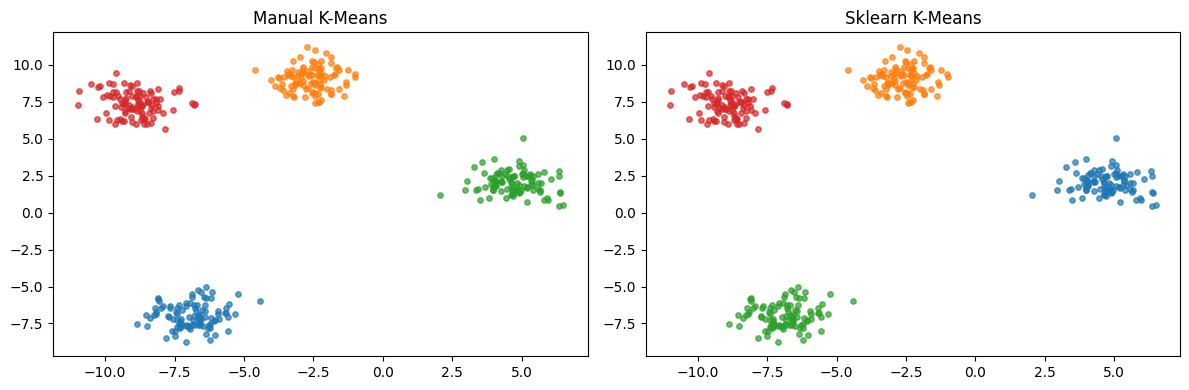

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans as sklearn_KMeans
from sklearn.datasets import make_blobs, make_moons

rng = np.random.default_rng(42)


class KMeans:
    """
    K-Means clustering with K-Means++ initialization.
    Convergence: when centroids stop moving.
    """
    def __init__(self, k: int, max_iter: int = 300, tol: float = 1e-6, rng=None):
        self.k        = k
        self.max_iter = max_iter
        self.tol      = tol
        self.rng      = rng or np.random.default_rng()
        self.centroids_   = None
        self.labels_      = None
        self.inertia_     = None
        self.n_iter_      = 0

    def _init_centroids_plusplus(self, X: np.ndarray) -> np.ndarray:
        """K-Means++ initialization: spread initial centroids."""
        n = len(X)
        first = self.rng.integers(0, n)
        centroids = [X[first]]

        for _ in range(self.k - 1):
            dists = np.array([
                min(np.sum((x - c)**2) for c in centroids) for x in X
            ])
            probs = dists / dists.sum()
            next_c = self.rng.choice(n, p=probs)
            centroids.append(X[next_c])

        return np.array(centroids)

    def _assign(self, X: np.ndarray, centroids: np.ndarray) -> np.ndarray:
        """Assign each point to nearest centroid."""
        # Vectorized: distance matrix (n x k)
        dists = np.linalg.norm(X[:, None] - centroids[None], axis=2)
        return dists.argmin(axis=1)

    def fit(self, X: np.ndarray) -> 'KMeans':
        centroids = self._init_centroids_plusplus(X)

        for i in range(self.max_iter):
            labels    = self._assign(X, centroids)
            new_cents = np.array([
                X[labels == j].mean(axis=0) if (labels == j).any() else centroids[j]
                for j in range(self.k)
            ])
            shift = np.linalg.norm(new_cents - centroids)
            centroids = new_cents
            if shift < self.tol:
                self.n_iter_ = i + 1
                break

        self.centroids_ = centroids
        self.labels_    = labels
        self.inertia_   = float(np.sum([
            np.sum((X[labels == j] - centroids[j])**2)
            for j in range(self.k)
        ]))
        return self

    def predict(self, X: np.ndarray) -> np.ndarray:
        return self._assign(X, self.centroids_)


# Test on blobs
X_blobs, y_blobs = make_blobs(n_samples=400, centers=4, cluster_std=0.8, random_state=42)

km = KMeans(k=4, rng=rng)
km.fit(X_blobs)

# Compare to sklearn
km_sk = sklearn_KMeans(n_clusters=4, random_state=42, n_init=10)
km_sk.fit(X_blobs)

print(f"Manual inertia:  {km.inertia_:.2f}")
print(f"Sklearn inertia: {km_sk.inertia_:.2f}  (sklearn runs multiple inits)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, labels, title in [
    (axes[0], km.labels_,         'Manual K-Means'),
    (axes[1], km_sk.labels_,      'Sklearn K-Means'),
]:
    for c in np.unique(labels):
        ax.scatter(X_blobs[labels==c, 0], X_blobs[labels==c, 1], s=15, alpha=0.7)
    ax.set_title(title)

plt.tight_layout()
plt.show()

## 3. Choosing K — The Elbow Method

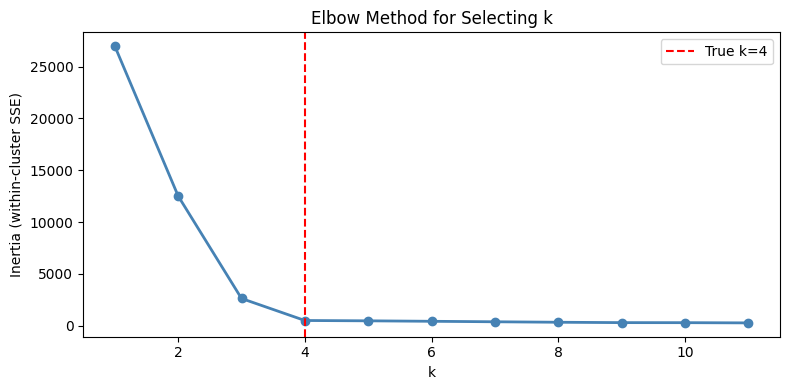

In [2]:
# Elbow method: plot inertia vs k, look for the kink
k_range  = range(1, 12)
inertias = []

for k in k_range:
    km_k = KMeans(k=k, rng=rng)
    km_k.fit(X_blobs)
    inertias.append(km_k.inertia_)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(list(k_range), inertias, 'o-', color='steelblue', lw=2)
ax.axvline(4, color='red', ls='--', label='True k=4')
ax.set_xlabel('k')
ax.set_ylabel('Inertia (within-cluster SSE)')
ax.set_title('Elbow Method for Selecting k')
ax.legend()
plt.tight_layout()
plt.show()

## 4. K-Means Failure Modes and DBSCAN

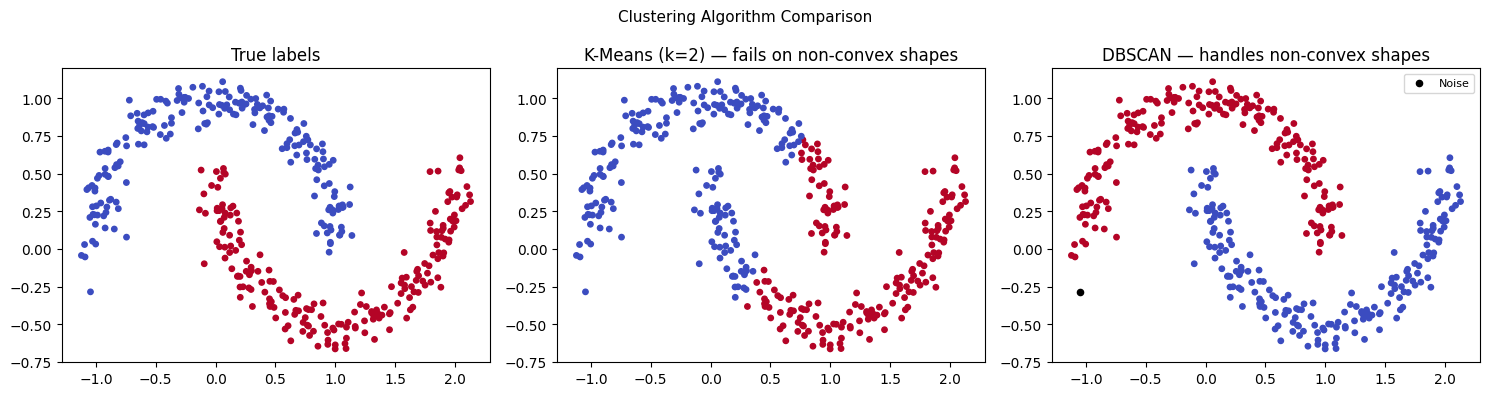

In [3]:
from sklearn.cluster import DBSCAN

# K-Means fails on non-convex shapes
X_moons, y_moons = make_moons(n_samples=400, noise=0.08, random_state=42)

km_moons   = KMeans(k=2, rng=rng).fit(X_moons)
db_moons   = DBSCAN(eps=0.2, min_samples=5).fit(X_moons)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(X_moons[:, 0], X_moons[:, 1], c=y_moons, cmap='coolwarm', s=15)
axes[0].set_title('True labels')

axes[1].scatter(X_moons[:, 0], X_moons[:, 1], c=km_moons.labels_, cmap='coolwarm', s=15)
axes[1].set_title('K-Means (k=2) — fails on non-convex shapes')

noise_mask = db_moons.labels_ == -1
axes[2].scatter(X_moons[~noise_mask, 0], X_moons[~noise_mask, 1],
               c=db_moons.labels_[~noise_mask], cmap='coolwarm', s=15)
axes[2].scatter(X_moons[noise_mask, 0], X_moons[noise_mask, 1],
               color='black', s=20, label='Noise', zorder=5)
axes[2].set_title('DBSCAN — handles non-convex shapes')
axes[2].legend(fontsize=8)

plt.suptitle('Clustering Algorithm Comparison', fontsize=11)
plt.tight_layout()
plt.show()

## 5. Cluster Evaluation

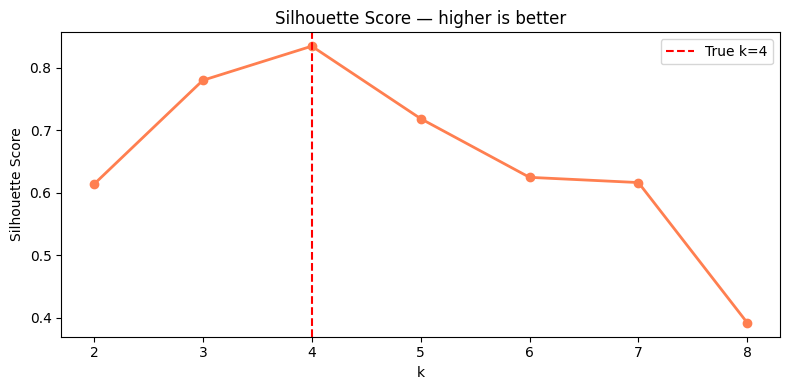

In [4]:
def silhouette_score(X: np.ndarray, labels: np.ndarray) -> float:
    """
    Silhouette score: mean of per-point silhouette coefficients.
    s(i) = (b(i) - a(i)) / max(a(i), b(i))
    a = mean dist to same-cluster points
    b = mean dist to nearest other-cluster points
    Range: [-1, 1]. Higher is better.
    """
    unique = np.unique(labels)
    if len(unique) < 2:
        return 0.0

    sil = []
    for i in range(len(X)):
        c_i = labels[i]
        same  = X[labels == c_i]
        a_i   = np.mean(np.linalg.norm(same - X[i], axis=1)) if len(same) > 1 else 0
        b_i   = min(
            np.mean(np.linalg.norm(X[labels == c] - X[i], axis=1))
            for c in unique if c != c_i
        )
        denom = max(a_i, b_i)
        sil.append((b_i - a_i) / denom if denom > 0 else 0)
    return float(np.mean(sil))

# Evaluate clustering quality across k values
silhouettes = []
for k in range(2, 9):
    km_k = KMeans(k=k, rng=rng)
    km_k.fit(X_blobs)
    # Use a subsample for speed
    idx = rng.choice(len(X_blobs), 100, replace=False)
    s = silhouette_score(X_blobs[idx], km_k.predict(X_blobs[idx]))
    silhouettes.append(s)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(2, 9), silhouettes, 'o-', color='coral', lw=2)
ax.axvline(4, color='red', ls='--', label='True k=4')
ax.set_xlabel('k')
ax.set_ylabel('Silhouette Score')
ax.set_title('Silhouette Score — higher is better')
ax.legend()
plt.tight_layout()
plt.show()

## 6. What Comes Next

Clustering assigns labels without supervision. **ch294 — Classification** uses those labels (or externally provided ones) to train a model that predicts the class of new points. The decision boundary a classifier learns is the supervised analogue of the cluster boundary K-Means finds. NMI from ch290 is the standard metric for comparing cluster quality against ground truth, used both here and in ch294's evaluation.